# Demand Forecasting using Linear Regression and Prophet
## Project: Product Placement Optimisation
## Student: Samikshya Baniya
## Student ID: 230360
## Module: ST6001CEM Individual Project

### Purpose
Build supervised machine learning models to forecast future monthly revenue for Baniya Shopping Center. This notebook adds proper predictive ML to the project, complementing the descriptive analysis in notebooks 01 to 09.

### Why Demand Forecasting?
Notebooks 01 to 09 looked BACKWARDS at what customers bought in the past. This notebook looks FORWARD. It trains models on 10 months of real revenue data and predicts what the next months will look like. This helps the store owner plan stock, staffing and promotions in advance.

### Models Used
1. Linear Regression - learns the overall sales trend
2. Prophet - detects seasonal patterns automatically including Dashain peak

### Input
data/processed/sales_data_cleaned.csv

### Output
Monthly revenue forecasts for the next 3 months with confidence intervals

## Why This is Machine Learning

Linear Regression and Prophet are both supervised machine learning models. Here is what supervised ML means in simple words:

- You give the model historical data (input) and the correct answers (output)
- The model learns the relationship between input and output
- You then give it new input it has never seen and it predicts the output

In our case:
- Input: month number (1 to 10)
- Output: revenue for that month
- The model learns the trend and seasonal pattern
- We then ask it to predict months 11, 12 and 13

This is different from K-Means clustering which is unsupervised. Supervised ML requires training data with known correct answers, which we have. This directly justifies the Machine Learning claim in the project title.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load and Prepare Monthly Revenue Data

In [2]:
df = pd.read_csv(
    r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\data\processed\sales_data_cleaned.csv'
)

df['date'] = pd.to_datetime(df['date'], dayfirst=True, errors='coerce')

print("Data loaded!")
print(f"Total rows: {len(df):,}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Data loaded!
Total rows: 767,180
Date range: 2025-07-17 00:00:00 to 2026-05-20 00:00:00


In [3]:
monthly = df.groupby(df['date'].dt.to_period('M'))['total_amount'].sum().reset_index()
monthly.columns = ['month', 'revenue']
monthly['month_str'] = monthly['month'].astype(str)
monthly['month_num'] = range(1, len(monthly) + 1)

print("Monthly Revenue Data")
print("=" * 50)
print(f"Total months: {len(monthly)}")
print()
for _, row in monthly.iterrows():
    print(f"  Month {row['month_num']:2d} - {row['month_str']}: Rs {row['revenue']:>15,.0f}")

print(f"\nTotal revenue: Rs {monthly['revenue'].sum():,.0f}")
print(f"Average monthly revenue: Rs {monthly['revenue'].mean():,.0f}")
print(f"Highest month: {monthly.loc[monthly['revenue'].idxmax(), 'month_str']} at Rs {monthly['revenue'].max():,.0f}")

Monthly Revenue Data
Total months: 11

  Month  1 - 2025-07: Rs       9,362,753
  Month  2 - 2025-08: Rs      21,698,971
  Month  3 - 2025-09: Rs      23,254,753
  Month  4 - 2025-10: Rs      21,071,996
  Month  5 - 2025-11: Rs      19,852,159
  Month  6 - 2025-12: Rs      21,855,134
  Month  7 - 2026-01: Rs      21,691,179
  Month  8 - 2026-02: Rs      20,789,960
  Month  9 - 2026-03: Rs      22,311,555
  Month 10 - 2026-04: Rs      22,061,335
  Month 11 - 2026-05: Rs      14,264,661

Total revenue: Rs 218,214,457
Average monthly revenue: Rs 19,837,678
Highest month: 2025-09 at Rs 23,254,753


## Step 3: Visualise Monthly Revenue Trend

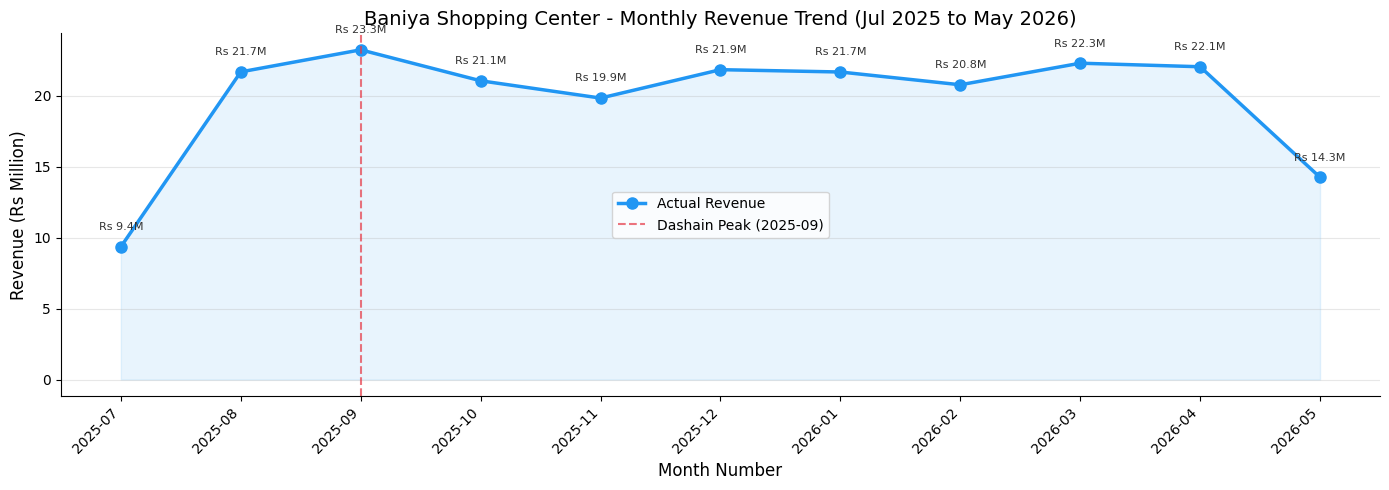

Chart 19 saved!


In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly['month_num'],
    monthly['revenue'] / 1_000_000,
    color='#2196F3',
    linewidth=2.5,
    marker='o',
    markersize=8,
    label='Actual Revenue'
)

ax.fill_between(
    monthly['month_num'],
    monthly['revenue'] / 1_000_000,
    alpha=0.1,
    color='#2196F3'
)

for _, row in monthly.iterrows():
    ax.annotate(
        f"Rs {row['revenue']/1_000_000:.1f}M",
        xy=(row['month_num'], row['revenue'] / 1_000_000),
        xytext=(0, 12),
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color='#333333'
    )

max_idx = monthly['revenue'].idxmax()
ax.axvline(
    x=monthly.loc[max_idx, 'month_num'],
    color='#e63946',
    linestyle='--',
    alpha=0.7,
    label=f"Dashain Peak ({monthly.loc[max_idx, 'month_str']})"
)

ax.set_xlabel('Month Number', fontsize=12)
ax.set_ylabel('Revenue (Rs Million)', fontsize=12)
ax.set_title('Baniya Shopping Center - Monthly Revenue Trend (Jul 2025 to May 2026)', fontsize=14)
ax.set_xticks(monthly['month_num'])
ax.set_xticklabels(monthly['month_str'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

figures_path = r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\reports\figures'
plt.savefig(f'{figures_path}/chart19_monthly_revenue_trend.png', dpi=150)
plt.show()
print("Chart 19 saved!")

## Step 4: Train Linear Regression Model